# RG3 — 전처리 데이터 생성 및 이해

팀 공통 전처리 파일 `data/2_Preprocessed_Data.csv`를 **전처리 설명대로** 다시 만들어 덮어쓰고, 모델링 전에 데이터를 이해한다.

전처리 설명 (팀 공유):
1. 원 센서 24개: 평균 0 표준화 상태 그대로
2. `Virtual_ID`: 0 = 앞쪽 부품(캐비티 0), 1 = 뒤쪽 부품(캐비티 1) — 한 번 사출에 부품 2개가 나와 같은 샷이 두 행으로 기록됨
3. 주요 센서 8개의 `_EMA10`(최근 10번 사출 평균), `_EMA3`(최근 3번 사출 평균), `_DIFF`(직전 샷 대비 변화량)
4. `PassOrFail`: 0 양품, 1 불량

기존 팀 파일은 2·3번이 설명과 다르게 계산되어 있었다(행 순서 기준 번호·이동평균, DIFF = 현재값 − EMA10).
이 노트북은 설명대로 **샷 단위**로 다시 계산한다. 열 이름·순서·행 순서(원본 라벨 파일과 동일)는 기존 파일과 같게 유지한다.

- 입력: `data/moldset_labeled_rg3.csv` (원본 라벨 데이터)
- 출력: `data/2_Preprocessed_Data.csv` (덮어씀) / 그래프 `outputs/figures/`, 표 `outputs/tables/` (접두어 `d_`)

# 0. 준비

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy import stats

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = next((f for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic'] if f in installed_fonts),
                                   'DejaVu Sans')
plt.rcParams.update({'axes.unicode_minus': False, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'figure.dpi': 110,
                     'savefig.dpi': 150, 'savefig.bbox': 'tight'})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

SEED = 42
np.random.seed(SEED)

C_BLUE, C_ORANGE, C_RED, C_GRAY, INK2 = '#2a78d6', '#eb6834', '#e34948', '#9a9892', '#52514e'
DATA, FIG, TAB = Path('data'), Path('outputs/figures'), Path('outputs/tables')
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)

TARGET = 'PassOrFail'
# 파생변수를 만드는 센서 8개와 열 순서 (기존 팀 파일과 동일하게 유지)
EMA_SENSORS = ['Average_Back_Pressure', 'Clamp_Close_Time', 'Cushion_Position', 'Max_Injection_Speed',
               'Plasticizing_Time', 'Cycle_Time', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure']
SUFFIXES = ['EMA10', 'EMA3', 'DIFF']

# 1. 전처리

### 1-1. 원본 불러오기와 샷(쌍) 식별

In [2]:
raw = pd.read_csv(DATA / 'moldset_labeled_rg3.csv', index_col=0)   # index = 원본 'Unnamed: 0' (시간 순서)
BASE = [c for c in raw.columns if c != TARGET]                     # 원 센서 24개
print(raw.shape, '| 원 센서', len(BASE))

# 같은 샷 = 원 센서 24개 값이 완전히 같은 행 묶음 (한 번 사출 → 부품 2개 → 2행)
shot_key = raw.groupby(BASE, sort=False).ngroup()
first_seen = raw.index.to_series().groupby(shot_key).transform('min')
shot_order = first_seen.rank(method='dense').astype(int) - 1      # 샷 순서 = 그 샷이 처음 기록된 시점 순
pair_pos = raw.index.to_series().groupby(shot_order).rank(method='first').astype(int) - 1   # 쌍 안에서 먼저 기록된 부품 = 0

sizes = shot_order.value_counts().value_counts().to_dict()
print('샷 수:', shot_order.nunique(), '| 샷당 행 수:', sizes, '| 쌍 안 위치:', pair_pos.value_counts().to_dict())

(1182, 25) | 원 센서 24
샷 수: 591 | 샷당 행 수: {2: 591} | 쌍 안 위치: {0: 591, 1: 591}


### 1-2. 설명대로 파생변수 생성

- `Virtual_ID` = 쌍 안에서 먼저 기록된 부품 0, 나중 부품 1 (캐비티 위치 가정)
- 이동평균·변화량은 **샷 순서**로 계산한다. 두 부품은 같은 샷의 같은 센서값이므로 샷당 한 번만 반영한다.
  - `_EMA10` / `_EMA3`: 최근 10샷 / 3샷 지수이동평균 (현재 샷 포함, pandas `ewm(span=…)` 기본값)
  - `_DIFF`: 현재 샷 − 직전 샷 (첫 샷은 0)
- 모두 현재까지의 센서값만 쓰므로 미래 정보나 라벨이 들어가지 않는다.

In [3]:
shots = raw[BASE].groupby(shot_order.values).first().sort_index()   # 591샷 × 24 (샷 순서)

feat = {}
for c in EMA_SENSORS:
    s = shots[c]
    feat[f'{c}_EMA10'] = s.ewm(span=10).mean()
    feat[f'{c}_EMA3'] = s.ewm(span=3).mean()
    feat[f'{c}_DIFF'] = s.diff().fillna(0.0)
shot_feat = pd.DataFrame(feat)
DERIVED = [f'{c}_{s}' for c in EMA_SENSORS for s in SUFFIXES]

pre = raw[BASE].copy()
pre['Virtual_ID'] = pair_pos.values
pre = pre.join(shot_feat.reindex(shot_order.values).set_axis(raw.index)[DERIVED])
pre[TARGET] = raw[TARGET]
COLUMNS = BASE + ['Virtual_ID'] + DERIVED + [TARGET]
pre = pre[COLUMNS]
print(pre.shape)
pre.head(6)

(1182, 50)


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Virtual_ID,Average_Back_Pressure_EMA10,Average_Back_Pressure_EMA3,Average_Back_Pressure_DIFF,Clamp_Close_Time_EMA10,Clamp_Close_Time_EMA3,Clamp_Close_Time_DIFF,Cushion_Position_EMA10,Cushion_Position_EMA3,Cushion_Position_DIFF,Max_Injection_Speed_EMA10,Max_Injection_Speed_EMA3,Max_Injection_Speed_DIFF,Plasticizing_Time_EMA10,Plasticizing_Time_EMA3,Plasticizing_Time_DIFF,Cycle_Time_EMA10,Cycle_Time_EMA3,Cycle_Time_DIFF,Max_Injection_Pressure_EMA10,Max_Injection_Pressure_EMA3,Max_Injection_Pressure_DIFF,Max_Switch_Over_Pressure_EMA10,Max_Switch_Over_Pressure_EMA3,Max_Switch_Over_Pressure_DIFF,PassOrFail
1211,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,2.187583,0.677109,-0.421798,-2.077961,-1.184902,-1.330250,-1.306878,0.096629,-0.496175,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042,0,-1.306878,-1.306878,0.000000,1.033078,1.033078,0.0,2.867608,2.867608,0.000000,2.187583,2.187583,0.000000,1.977737,1.977737,0.000000,0.249511,0.249511,0.000000,-2.077961,-2.077961,0.00000,-1.184902,-1.184902,0.000000,0
1212,-0.029099,-1.192531,1.977737,0.249511,1.033078,2.867608,-1.755816,0.0,2.187583,0.677109,-0.421798,-2.077961,-1.184902,-1.330250,-1.306878,0.096629,-0.496175,-0.002081,0.047749,0.282727,-0.354184,0.183232,-1.393485,-1.576042,1,-1.306878,-1.306878,0.000000,1.033078,1.033078,0.0,2.867608,2.867608,0.000000,2.187583,2.187583,0.000000,1.977737,1.977737,0.000000,0.249511,0.249511,0.000000,-2.077961,-2.077961,0.00000,-1.184902,-1.184902,0.000000,0
1213,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,2.187583,0.677109,-0.421798,-1.421642,-0.974786,-1.019133,-0.841877,0.562844,1.442567,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042,0,-1.051127,-0.996877,0.465001,1.033078,1.033078,0.0,2.431722,2.339262,-0.792519,2.187583,2.187583,0.000000,1.730810,1.678431,-0.448960,0.249511,0.249511,0.000000,-1.716986,-1.640415,0.65632,-1.069338,-1.044825,0.210116,0
1214,-0.029099,-1.192531,1.528778,0.249511,1.033078,2.075089,-0.192928,0.0,2.187583,0.677109,-0.421798,-1.421642,-0.974786,-1.019133,-0.841877,0.562844,1.442567,-0.002081,0.340262,1.850096,-0.851297,0.183232,-1.535968,-1.576042,1,-1.051127,-0.996877,0.465001,1.033078,1.033078,0.0,2.431722,2.339262,-0.792519,2.187583,2.187583,0.000000,1.730810,1.678431,-0.448960,0.249511,0.249511,0.000000,-1.716986,-1.640415,0.65632,-1.069338,-1.044825,0.210116,0
1215,-0.029099,-1.192531,0.630880,-0.298708,1.033078,1.277707,-1.755816,0.0,1.402554,0.677109,2.655764,-0.765222,-0.554587,-0.708027,-1.539374,1.262095,-0.253813,-0.002081,0.925242,0.282727,-1.348485,0.284910,-1.535968,-1.576042,0,-1.247399,-1.306875,-0.697497,1.033078,1.033078,0.0,1.967816,1.732659,-0.797381,1.872007,1.738995,-0.785029,1.288645,1.079830,-0.897898,0.029131,-0.063757,-0.548218,-1.334383,-1.140305,0.65642,-0.862411,-0.764689,0.420199,0
1216,-0.029099,-1.192531,0.630880,-0.298708,1.033078,1.277707,-1.755816,0.0,1.402554,0.677109,2.655764,-0.765222,-0.554587,-0.708027,-1.539374,1.262095,-0.253813,-0.002081,0.925242,0.282727,-1.348485,0.284910,-1.535968,-1.576042,1,-1.247399,-1.306875,-0.697497,1.033078,1.033078,0.0,1.967816,1.732659,-0.797381,1.872007,1.738995,-0.785029,1.288645,1.079830,-0.897898,0.029131,-0.063757,-0.548218,-1.334383,-1.140305,0.65642,-0.862411,-0.764689,0.420199,0


### 1-3. 기존 팀 파일 방식과 비교

기존 방식(행 순서 짝·홀 번호, 행 기준 이동평균, DIFF = 현재값 − EMA10)을 원본에서 그대로 재현해, 무엇이 바뀌었는지 기록한다.

In [4]:
old = raw[BASE].copy()
old['Virtual_ID'] = (np.arange(len(raw)) % 2)
for c in EMA_SENSORS:
    x = raw[c]
    old[f'{c}_EMA10'] = x.ewm(span=10).mean()
    old[f'{c}_EMA3'] = x.ewm(span=3).mean()
    old[f'{c}_DIFF'] = x - old[f'{c}_EMA10']
old[TARGET] = raw[TARGET]

team_file = DATA / '2_Preprocessed_Data.csv'
if team_file.exists():   # 기존 파일이 아직 팀 버전이면 재현이 맞는지 확인
    cur = pd.read_csv(team_file)
    print('현재 파일 = 기존 팀 방식 재현:', np.allclose(cur[COLUMNS].values, old[COLUMNS].values, atol=1e-9),
          '| 현재 파일 = 새 방식:', np.allclose(cur[COLUMNS].values, pre[COLUMNS].values, atol=1e-9))

changes = pd.DataFrame({
    '항목': ['Virtual_ID', 'EMA10 (8개)', 'EMA3 (8개)', 'DIFF (8개)'],
    '기존 방식': ['행 순서 짝·홀', '행 순서 ewm(span=10) ≈ 5샷', '행 순서 ewm(span=3) ≈ 1.5샷', '현재값 − EMA10'],
    '새 방식': ['쌍 안 기록 순서 (먼저 0)', '샷 순서 ewm(span=10)', '샷 순서 ewm(span=3)', '현재 샷 − 직전 샷'],
    '값이 바뀐 행': [int((pre['Virtual_ID'] != old['Virtual_ID']).sum())] +
                 [int((~np.isclose(pre[[f'{c}_{s}' for c in EMA_SENSORS]], old[[f'{c}_{s}' for c in EMA_SENSORS]])).any(axis=1).sum())
                  for s in SUFFIXES],
})
changes.to_csv(TAB / 'd_preprocess_changes.csv', index=False, encoding='utf-8-sig')
changes

현재 파일 = 기존 팀 방식 재현: False | 현재 파일 = 새 방식: True


,항목,기존 방식,새 방식,값이 바뀐 행
0,Virtual_ID,행 순서 짝·홀,쌍 안 기록 순서 (먼저 0),26
1,EMA10 (8개),행 순서 ewm(span=10) ≈ 5샷,샷 순서 ewm(span=10),1180
2,EMA3 (8개),행 순서 ewm(span=3) ≈ 1.5샷,샷 순서 ewm(span=3),1180
3,DIFF (8개),현재값 − EMA10,현재 샷 − 직전 샷,1180


### 1-4. 저장 (덮어쓰기)

In [5]:
pre.to_csv(team_file, index=False)          # 기존 팀 파일과 같은 형식: 인덱스 없음, 1,182행 × 50열
chk = pd.read_csv(team_file)
print(team_file, chk.shape, '| 열 순서 유지:', list(chk.columns) == COLUMNS,
      '| 라벨·원 센서 원본과 동일:', np.allclose(chk[BASE].values, raw[BASE].values) and (chk[TARGET].values == raw[TARGET].values).all())

data\2_Preprocessed_Data.csv (1182, 50) | 열 순서 유지: True | 라벨·원 센서 원본과 동일: True


# 2. 설명과 일치하는지 검증

In [6]:
df = pd.read_csv(team_file)
df.index = raw.index                       # 원본 인덱스(시간 순서) 복원
df['shot_id'] = shot_order.values
g = df.groupby('shot_id')

verify = pd.Series({
    '샷마다 Virtual_ID가 0과 1로 하나씩': bool((g['Virtual_ID'].agg(sorted).apply(tuple) == (0, 1)).all()),
    '같은 샷 두 부품의 파생변수가 같음': bool((g[DERIVED].nunique() == 1).all().all()),
    'DIFF = 현재 샷 − 직전 샷': bool(np.allclose(shot_feat[[f'{c}_DIFF' for c in EMA_SENSORS]].values,
                                            shots[EMA_SENSORS].diff().fillna(0).values)),
    '원 센서·라벨은 원본 그대로': bool(np.allclose(df[BASE].values, raw[BASE].values) and (df[TARGET] == raw[TARGET]).all()),
}, name='결과')
verify.to_frame()

,결과
샷마다 Virtual_ID가 0과 1로 하나씩,True
같은 샷 두 부품의 파생변수가 같음,True
DIFF = 현재 샷 − 직전 샷,True
원 센서·라벨은 원본 그대로,True


# 3. 데이터 이해

### 3-1. 기본 구조

In [7]:
summary = pd.DataFrame({'mean': df[BASE].mean(), 'std': df[BASE].std(), 'nunique': df[BASE].nunique()})
print('결측치:', int(df.isna().sum().sum()), '| 샷 수:', df['shot_id'].nunique())
print(df[TARGET].value_counts().to_dict())
summary.round(3).T

결측치: 0 | 샷 수: 591
{0: 1157, 1: 25}


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
mean,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
nunique,3.0,2.0,27.0,10.0,3.0,7.0,8.0,1.0,7.0,4.0,4.0,10.0,17.0,16.0,21.0,25.0,22.0,17.0,30.0,21.0,12.0,52.0,26.0,29.0


> - 1,182행 = 591샷 × 부품 2개. 같은 샷의 두 행은 원 센서값과 파생변수가 모두 같고 `Virtual_ID`만 다르다.
> - `Clamp_Open_Position`은 모든 행이 같은 값(상수)이라 정보가 없다.
> - 원 센서는 라벨 파일 안에서만 표준화된 값이다. 비라벨 파일과 함께 쓰려면 `outputs/tables/inverse_transform_coef.csv`의 역변환(a, b)이 필요하다.

### 3-2. `Virtual_ID`와 불량

In [8]:
fail = df[df[TARGET] == 1]
tab = pd.crosstab(df['Virtual_ID'], df[TARGET], margins=True).rename(columns={0: '양품', 1: '불량', 'All': '합계'})
tab['불량률'] = (tab['불량'] / tab['합계']).round(4)
bt = stats.binomtest(int((fail['Virtual_ID'] == 0).sum()), len(fail), 0.5)
print(f"불량 25건 중 Virtual_ID=0: {(fail['Virtual_ID'] == 0).sum()}건 (반반 가정 이항검정 p = {bt.pvalue:.1e})")
print('불량이 있는 샷:', fail['shot_id'].nunique(), '| 샷 안의 불량 수:', fail.groupby('shot_id').size().value_counts().to_dict())
tab

불량 25건 중 Virtual_ID=0: 23건 (반반 가정 이항검정 p = 1.9e-05)
불량이 있는 샷: 25 | 샷 안의 불량 수: {1: 25}


PassOrFail,양품,불량,합계,불량률
Virtual_ID,,,,
0,568,23,591,0.0389
1,589,2,591,0.0034
All,1157,25,1182,0.0212


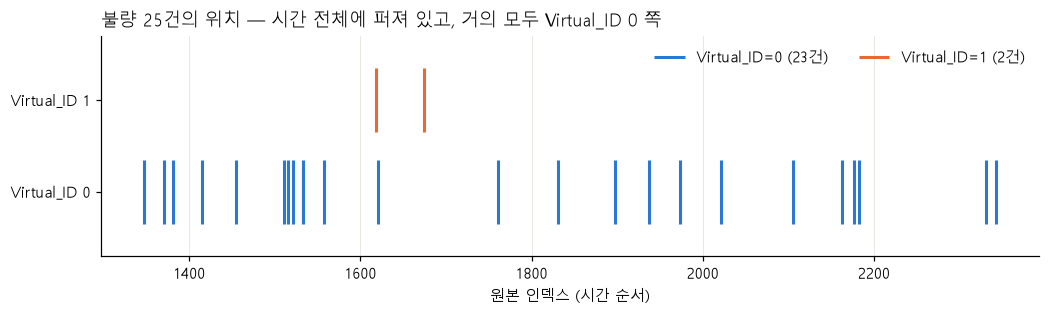

In [9]:
fig, ax = plt.subplots(figsize=(11, 2.6))
for vid, c in ((0, C_BLUE), (1, C_ORANGE)):
    f = fail[fail['Virtual_ID'] == vid]
    ax.vlines(f.index, vid - 0.35, vid + 0.35, color=c, lw=2, label=f'Virtual_ID={vid} ({len(f)}건)')
ax.set_yticks([0, 1], ['Virtual_ID 0', 'Virtual_ID 1']); ax.set_ylim(-0.7, 1.7); ax.grid(axis='y', visible=False)
ax.set_xlabel('원본 인덱스 (시간 순서)'); ax.legend(loc='upper right', ncol=2, frameon=False)
ax.set_title('불량 25건의 위치 — 시간 전체에 퍼져 있고, 거의 모두 Virtual_ID 0 쪽', loc='left')
fig.savefig(FIG / 'd_defect_position.png'); plt.show()

> - 불량 25건은 모두 서로 다른 샷이고, 샷마다 부품 하나만 불량이다. 그중 **23건이 `Virtual_ID = 0`** (p = 1.9e-05).
> - 같은 샷의 불량 부품과 양품 부품은 `Virtual_ID` 외에 모든 값이 같다. 즉 **샷 안에서 어느 부품이 불량인지는 `Virtual_ID`로만 구별**된다.
> - 주의: `Virtual_ID`는 원본에 있던 캐비티 번호가 아니라 기록 순서로 매긴 값이다. 치우침이 실제 캐비티 차이인지,
>   원본이 불량 부품을 먼저 기록한 흔적(정답 누수)인지는 이 데이터만으로 구별할 수 없다.

### 3-3. 불량 샷 vs 양품 샷: 변수별 차이

In [10]:
# 두 부품의 공정값이 같으므로 샷 단위로 비교 (샷 라벨 = 부품 중 하나라도 불량이면 1)
shot_df = df.groupby('shot_id').agg({**{c: 'first' for c in BASE + DERIVED}, TARGET: 'max'})
feats = [c for c in BASE + DERIVED if shot_df[c].nunique() > 1]
res = []
for c in feats:
    a, b = shot_df.loc[shot_df[TARGET] == 1, c], shot_df.loc[shot_df[TARGET] == 0, c]
    sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    res.append({'feature': c, 'type': '원 센서' if c in BASE else '파생',
                'smd(불량-양품)': (a.mean() - b.mean()) / sd, 'p(Mann-Whitney)': stats.mannwhitneyu(a, b).pvalue})
uni = pd.DataFrame(res)
uni['q(BH-FDR)'] = stats.false_discovery_control(uni['p(Mann-Whitney)'])
uni = uni.sort_values('p(Mann-Whitney)').reset_index(drop=True)
uni.to_csv(TAB / 'd_univariate_defect_vs_normal.csv', index=False, encoding='utf-8-sig')
print(f'샷 {len(shot_df)}개 (불량 샷 {int(shot_df[TARGET].sum())}개) | 보정 후 유의(q < 0.05):',
      int((uni['q(BH-FDR)'] < 0.05).sum()), '/', len(uni))
uni.head(10).round(4)

샷 591개 (불량 샷 25개) | 보정 후 유의(q < 0.05): 0 / 47


,feature,type,smd(불량-양품),p(Mann-Whitney),q(BH-FDR)
0,Barrel_Temperature_5,원 센서,0.4845,0.0182,0.8576
1,Average_Back_Pressure_DIFF,파생,0.3319,0.0888,0.9985
2,Max_Injection_Speed_DIFF,파생,0.2285,0.2109,0.9985
3,Cycle_Time_DIFF,파생,0.1606,0.2221,0.9985
4,Plasticizing_Time_EMA3,파생,0.1304,0.2763,0.9985
5,Plasticizing_Time,원 센서,0.1949,0.2906,0.9985
6,Cycle_Time,원 센서,0.0108,0.3516,0.9985
7,Clamp_Close_Time,원 센서,0.1967,0.3873,0.9985
8,Barrel_Temperature_3,원 센서,-0.1624,0.3974,0.9985
9,Plasticizing_Time_EMA10,파생,0.0228,0.4011,0.9985


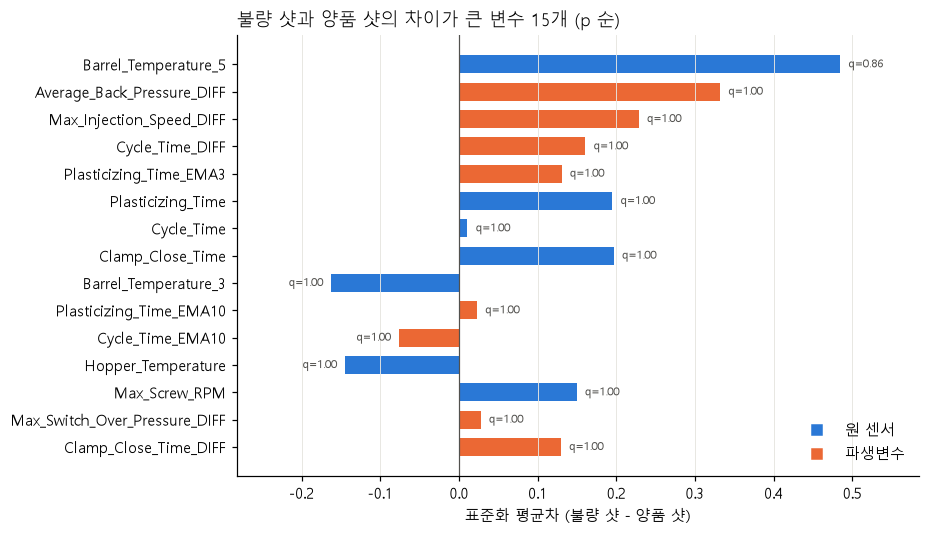

In [11]:
top = uni.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(top['feature'], top['smd(불량-양품)'], color=[C_BLUE if t == '원 센서' else C_ORANGE for t in top['type']], height=0.65)
ax.axvline(0, color=INK2, lw=0.8); ax.grid(axis='y', visible=False)
for i, (v, q) in enumerate(zip(top['smd(불량-양품)'], top['q(BH-FDR)'])):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'q={q:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=7.5, color=INK2)
ax.plot([], [], 's', color=C_BLUE, label='원 센서'); ax.plot([], [], 's', color=C_ORANGE, label='파생변수')
ax.legend(loc='lower right', frameon=False)
lo, hi = top['smd(불량-양품)'].min(), top['smd(불량-양품)'].max()
ax.set_xlim(min(lo, 0) - 0.12, hi + 0.1)
ax.set_xlabel('표준화 평균차 (불량 샷 - 양품 샷)')
ax.set_title('불량 샷과 양품 샷의 차이가 큰 변수 15개 (p 순)', loc='left')
fig.savefig(FIG / 'd_univariate_top15.png'); plt.show()

> - 불량 샷 25개와 양품 샷 566개를 비교하면, 원 센서·파생변수 47개 모두 **다중검정 보정 후 유의한 차이가 없다** (가장 작은 q = 0.86, `Barrel_Temperature_5`).
> - 원 센서·파생변수는 같은 샷의 두 부품이 같은 값이라, **샷 안에서** 어느 부품이 불량인지는 구별할 수 없다. 이 변수들이 줄 수 있는 정보는 "불량이 나오는 샷"을 고르는 데까지다.

### 3-4. 파생변수와 원 센서의 중복

In [12]:
red = pd.DataFrame({c: {'corr(원값, EMA3)': shot_df[c].corr(shot_df[c + '_EMA3']),
                        'corr(원값, EMA10)': shot_df[c].corr(shot_df[c + '_EMA10']),
                        'corr(원값, DIFF)': shot_df[c].corr(shot_df[c + '_DIFF'])} for c in EMA_SENSORS}).T
red.round(3)

,"corr(원값, EMA3)","corr(원값, EMA10)","corr(원값, DIFF)"
Average_Back_Pressure,0.941,0.802,0.308
Clamp_Close_Time,0.977,0.934,0.226
Cushion_Position,0.925,0.780,0.407
Max_Injection_Speed,0.954,0.862,0.299
Plasticizing_Time,0.925,0.800,0.439
Cycle_Time,0.870,0.583,0.637
Max_Injection_Pressure,0.909,0.724,0.434
Max_Switch_Over_Pressure,0.888,0.667,0.568


> - EMA3는 원값과 상관 0.87~0.98로 거의 같은 정보다. EMA10은 0.58~0.93.
> - DIFF(직전 샷 대비 변화량)는 0.23~0.64로 원값과 겹침이 가장 적어, 새 정보를 줄 여지가 가장 크다.

# 4. 정리: 모델링 전에 알아둘 것

| 항목 | 내용 | 모델링 시 고려 |
|---|---|---|
| 데이터 단위 | 1,182행 = 591샷 × 부품 2개 | 교차검증은 **`shot_id`로 묶어** 나눈다 (같은 샷이 학습·평가로 갈리면 누수) |
| `Virtual_ID` | 쌍 안 기록 순서 (먼저 0). 불량 23/25가 0 | 샷 안의 불량 부품을 가르는 유일한 변수. 캐비티인지 기록 순서인지 미확인 → 넣은 모델/뺀 모델을 함께 보고 |
| 원 센서 24개 | 표준화 상태 그대로, `Clamp_Open_Position`은 상수 | 상수 열은 제외 |
| EMA3·EMA10·DIFF | 샷 기준 최근 3샷·10샷 평균, 직전 샷 대비 변화량. 같은 샷 두 부품은 같은 값 | 과거 샷만 사용 → 누수 없음 |
| 불량 | 25건 (샷 기준 25/591 = 4.2%) | 평가 fold당 불량이 약 5건이라 PR-AUC가 크게 흔들림 → 순열 기준선과 함께 보고 |

# 4. 모델링

**목표 (출제 배경)**: 최종 품질검사 이전에 불량 가능성이 높은 부품을 예측해 **검사 우선순위**를 정하고,
모델이 어떤 조건에서 작동하고 어떤 조건에서 실패하는지 분석한다.

| 설계 | 내용 |
|---|---|
| 예측 단위 | 부품(행). 한 샷의 부품 2개가 각각 양품/불량 판정을 받는다 |
| 교차검증 | 같은 샷의 두 부품이 학습·평가로 갈리지 않도록 `shot_id`로 묶은 5-fold × 10회 (`StratifiedGroupKFold`, 시드 42 + 반복번호) |
| 임계값 | F1 최대점, Recall ≥ 0.8 두 가지. 학습 fold 안에서 샷 단위 3-fold로만 결정 |
| 지표 | F1·Recall·Precision·PR-AUC(팀 공통), Recall@상위 k%, 목표 Recall에 필요한 검사율, ROC-AUC(참고) |

**후보 모델**

| 모델 | 입력 | 아이디어 |
|---|---|---|
| A. 캐비티 규칙 | `Virtual_ID` | 부품 불량 확률 = 학습 데이터에서 그 캐비티의 불량률 (평가 점수는 같은 순위인 캐비티 순서 0/1) |
| B. 공정 모델 (LogReg / HGB) | 공정 변수 47개 | 두 부품의 공정값이 같으므로 **샷 단위**로 학습해 "불량이 나오는 샷"을 예측 |
| C. 2단계 모델 | 공정 + `Virtual_ID` | 샷 불량 위험(B, LogReg) × 캐비티 불량률(A) |
| C'. 캐비티 우선 + 공정 순위 | 공정 + `Virtual_ID` | 캐비티 순서는 A 그대로, 같은 캐비티 안에서만 B(HGB) 순서 |
| D. 평면 HGB | 공정 + `Virtual_ID` | 모든 변수를 한 모델에 (비교용) |

### 4-1. 공통 설정

In [13]:
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

PROC = [c for c in BASE if df[c].nunique() > 1] + DERIVED        # 공정 변수 47개 (상수 열 제외)
Xp = df[PROC].to_numpy(); vid = df['Virtual_ID'].to_numpy(); y = df[TARGET].to_numpy(); grp = df['shot_id'].to_numpy()

N_SPLITS, N_REPEATS = 5, 10
SPLITS = [(r, tr, te) for r in range(N_REPEATS)
          for tr, te in StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=SEED + r).split(np.zeros(len(y)), y, grp)]
assert all(not set(grp[tr]) & set(grp[te]) for _, tr, te in SPLITS)     # 같은 샷이 학습·평가에 동시에 없음
print(len(SPLITS), 'folds | 평가 fold 평균 부품', round(np.mean([len(te) for *_, te in SPLITS]), 1),
      '| 평균 불량', round(np.mean([y[te].sum() for *_, te in SPLITS]), 1), '| 공정 변수', len(PROC))

50 folds | 평가 fold 평균 부품 236.4 | 평균 불량 5.0 | 공정 변수 47


In [14]:
def hgb():
    return HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, class_weight='balanced',
                                          random_state=SEED)

def shot_level(idx, X):
    s = pd.DataFrame({'g': grp[idx], 'y': y[idx], 'i': idx}).groupby('g').agg(y=('y', 'max'), i=('i', 'first'))
    return X[s['i'].values], s['y'].values

def fit_process(idx, kind='hgb', X=None):
    """B. 공정 모델: 샷 단위(두 부품 중 하나라도 불량이면 1)로 학습 → 샷 불량 위험"""
    X = Xp if X is None else X
    Xs, ys = shot_level(idx, X)
    m = hgb() if kind == 'hgb' else make_pipeline(StandardScaler(), LogisticRegression(C=0.1, class_weight='balanced', max_iter=5000))
    m.fit(Xs, ys)
    return lambda j: m.predict_proba(X[j])[:, 1]

def cavity_rates(idx):
    """학습 데이터의 캐비티별 불량률 (+0.5 / +1 보정) = 부품 불량 확률"""
    return np.array([(y[idx][vid[idx] == v].sum() + 0.5) / ((vid[idx] == v).sum() + 1) for v in (0, 1)])

def fit_cavity(idx):
    rate = cavity_rates(idx)
    return lambda j: rate[vid[j]]

def fit_cavity_rank(idx):
    """A. 캐비티 규칙 (평가용 점수): 불량률이 높은 캐비티 = 1, 낮은 캐비티 = 0.
    순위는 불량률과 같고, fold마다 불량률 값이 조금씩 달라 임계값이 흔들리는 문제를 막는다."""
    hi = int(np.argmax(cavity_rates(idx)))
    return lambda j: (vid[j] == hi).astype(float)

def fit_cavity_random_ties(idx):
    """A와 같지만 같은 캐비티 안 순서를 무작위로 (동점 때문에 PR-AUC가 낮게 계산되는 것 보정용)"""
    r = fit_cavity_rank(idx)
    return lambda j: r(j) + 1e-6 * np.random.default_rng(SEED + len(j)).random(len(j))

def fit_two_stage(idx, X=None):
    p, q = fit_process(idx, 'lr', X), fit_cavity(idx)
    return lambda j: p(j) * q(j)

def fit_cavity_then_process(idx, X=None):
    p, r = fit_process(idx, 'hgb', X), fit_cavity_rank(idx)
    return lambda j: r(j) + 0.5 * p(j)           # 캐비티 순서(0/1)가 항상 우선, 같은 캐비티 안에서만 공정 위험 순

def fit_flat(idx):
    Xf = np.c_[Xp, vid]
    m = hgb().fit(Xf[idx], y[idx])
    return lambda j: m.predict_proba(Xf[j])[:, 1]

MODELS = {
    'A 캐비티 규칙': fit_cavity_rank,
    'A 캐비티 규칙 (동점 무작위 순서)': fit_cavity_random_ties,
    'B 공정 LogReg': lambda i: fit_process(i, 'lr'),
    'B 공정 HGB': lambda i: fit_process(i, 'hgb'),
    'C 2단계 (공정 LogReg × 캐비티)': fit_two_stage,
    "C' 캐비티 우선 + 공정 HGB 순위": fit_cavity_then_process,
    'D 평면 HGB (공정 + Virtual_ID)': fit_flat,
}

In [15]:
def rank_order(s, seed):
    o = np.random.default_rng(seed).permutation(len(s))     # 동점은 시드 고정 무작위로
    return o[np.argsort(-s[o], kind='stable')]

def recall_at(yt, s, k, seed):
    return yt[rank_order(s, seed)[:int(np.ceil(k * len(yt)))]].sum() / yt.sum()

def inspect_rate_at(yt, s, target, seed):
    cum = np.cumsum(yt[rank_order(s, seed)]) / yt.sum()
    return (np.argmax(cum >= target - 1e-12) + 1) / len(yt)

def pick_thresholds(yt, s):
    p, r, t = precision_recall_curve(yt, s)
    p, r = p[:-1], r[:-1]
    f1 = np.where(p + r > 0, 2 * p * r / (p + r + 1e-12), 0)
    return {'F1max': t[np.argmax(f1)], 'Recall80': t[r >= 0.8].max()}

def evaluate(name, fit, rep, tr, te, fold):
    # 임계값: 학습 fold 안에서 샷 단위 3-fold OOF로만 결정
    oof = np.zeros(len(y))
    for itr, iva in StratifiedGroupKFold(3, shuffle=True, random_state=SEED).split(np.zeros(len(tr)), y[tr], grp[tr]):
        oof[tr[iva]] = fit(tr[itr])(tr[iva])
    thr = pick_thresholds(y[tr], oof[tr])
    s, yt = fit(tr)(te), y[te]
    out = {'model': name, 'fold': fold, 'prevalence': yt.mean(), 'prauc': average_precision_score(yt, s),
           'roc_auc': roc_auc_score(yt, s)}
    for k in (0.05, 0.10, 0.20, 0.50):
        out[f'recall@{int(k * 100)}%'] = recall_at(yt, s, k, SEED + fold)
    out['검사율@Recall0.8'] = inspect_rate_at(yt, s, 0.8, SEED + fold)
    out['검사율@Recall1.0'] = inspect_rate_at(yt, s, 1.0, SEED + fold)
    for rule, t in thr.items():
        flag = s >= t
        tp = int((flag & (yt == 1)).sum())
        P, R = tp / max(flag.sum(), 1), tp / yt.sum()
        out.update({f'precision_{rule}': P, f'recall_{rule}': R, f'f1_{rule}': 2 * P * R / (P + R) if tp else 0.0,
                    f'threshold_{rule}': t, f'검사율_{rule}': flag.mean()})
    return out, (name, te, s)

### 4-2. 후보 모델 비교 (샷 단위 묶음 5-fold × 10)

In [16]:
res = Parallel(n_jobs=-1)(delayed(evaluate)(n, f, r, tr, te, k)
                          for n, f in MODELS.items() for k, (r, tr, te) in enumerate(SPLITS))
folds = pd.DataFrame([r[0] for r in res])
OOF = {}
for name, te, s in (r[1] for r in res):
    OOF.setdefault(name, []).append((te, s))
folds.to_csv(TAB / 'm_cv_fold_metrics.csv', index=False, encoding='utf-8-sig')

show = ['prauc', 'recall@5%', 'recall@10%', 'recall@20%', 'recall@50%', '검사율@Recall0.8', '검사율@Recall1.0', 'roc_auc']
cmp = folds.groupby('model', sort=False)[show].agg(['mean', 'std'])
print('평가 fold 불량 비율(무작위 기준선 PR-AUC):', round(folds['prevalence'].mean(), 4))
cmp.xs('mean', axis=1, level=1).round(3)

평가 fold 불량 비율(무작위 기준선 PR-AUC): 0.0212


,prauc,recall@5%,recall@10%,recall@20%,recall@50%,검사율@Recall0.8,검사율@Recall1.0,roc_auc
model,,,,,,,,
A 캐비티 규칙,0.038,0.100,0.200,0.376,0.920,0.383,0.577,0.715
A 캐비티 규칙 (동점 무작위 순서),0.071,0.092,0.216,0.380,0.920,0.372,0.559,0.713
B 공정 LogReg,0.032,0.036,0.072,0.172,0.432,0.749,0.911,0.433
B 공정 HGB,0.038,0.068,0.088,0.176,0.444,0.714,0.867,0.467
C 2단계 (공정 LogReg × 캐비티),0.043,0.020,0.100,0.272,0.792,0.443,0.604,0.648
C' 캐비티 우선 + 공정 HGB 순위,0.073,0.088,0.176,0.340,0.920,0.382,0.584,0.698
D 평면 HGB (공정 + Virtual_ID),0.070,0.096,0.160,0.304,0.672,0.525,0.744,0.616


In [17]:
thr_cols = [f'{m}_{r}' for r in ('F1max', 'Recall80') for m in ('f1', 'precision', 'recall', '검사율')]
folds.groupby('model', sort=False)[thr_cols].mean().round(3)

,f1_F1max,precision_F1max,recall_F1max,검사율_F1max,f1_Recall80,precision_Recall80,recall_Recall80,검사율_Recall80
model,,,,,,,,
A 캐비티 규칙,0.075,0.039,0.920,0.500,0.075,0.039,0.920,0.500
A 캐비티 규칙 (동점 무작위 순서),0.057,0.039,0.336,0.193,0.073,0.038,0.788,0.432
B 공정 LogReg,0.023,0.012,0.364,0.421,0.037,0.019,0.844,0.921
B 공정 HGB,0.028,0.016,0.332,0.363,0.040,0.021,0.868,0.887
C 2단계 (공정 LogReg × 캐비티),0.046,0.025,0.436,0.292,0.058,0.030,0.828,0.591
C' 캐비티 우선 + 공정 HGB 순위,0.056,0.034,0.388,0.222,0.073,0.038,0.836,0.464
D 평면 HGB (공정 + Virtual_ID),0.036,0.023,0.200,0.149,0.047,0.024,0.848,0.741


In [18]:
# 팀 공통 결과표 (컬럼 순서 고정)
TEAM_COLS = ['model', 'product', 'f1_mean', 'f1_std', 'recall_mean', 'recall_std', 'precision_mean', 'precision_std',
             'prauc_mean', 'prauc_std', 'threshold']
rows = []
for name, g in folds.groupby('model', sort=False):
    for rule in ('F1max', 'Recall80'):
        rows.append({'model': f'{name}|thr={rule}', 'product': 'RG3',
                     'f1_mean': g[f'f1_{rule}'].mean(), 'f1_std': g[f'f1_{rule}'].std(),
                     'recall_mean': g[f'recall_{rule}'].mean(), 'recall_std': g[f'recall_{rule}'].std(),
                     'precision_mean': g[f'precision_{rule}'].mean(), 'precision_std': g[f'precision_{rule}'].std(),
                     'prauc_mean': g['prauc'].mean(), 'prauc_std': g['prauc'].std(), 'threshold': g[f'threshold_{rule}'].mean()})
team = pd.DataFrame(rows)[TEAM_COLS]
team.to_csv(TAB / 'model_comparison_RG3.csv', index=False, encoding='utf-8-sig')
team.round(4)

,model,product,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std,prauc_mean,prauc_std,threshold
0,A 캐비티 규칙|thr=F1max,RG3,0.0747,0.0086,0.920,0.1069,0.0389,0.0045,0.0380,0.0057,1.0000
1,A 캐비티 규칙|thr=Recall80,RG3,0.0747,0.0086,0.920,0.1069,0.0389,0.0045,0.0380,0.0057,1.0000
2,A 캐비티 규칙 (동점 무작위 순서)|thr=F1max,RG3,0.0568,0.0572,0.336,0.3367,0.0385,0.0575,0.0710,0.0544,1.0000
3,A 캐비티 규칙 (동점 무작위 순서)|thr=Recall80,RG3,0.0733,0.0165,0.788,0.2076,0.0384,0.0086,0.0710,0.0544,1.0000
4,B 공정 LogReg|thr=F1max,RG3,0.0229,0.0243,0.364,0.4095,0.0123,0.0137,0.0317,0.0203,0.4704
5,B 공정 LogReg|thr=Recall80,RG3,0.0374,0.0080,0.844,0.2187,0.0191,0.0041,0.0317,0.0203,0.0933
6,B 공정 HGB|thr=F1max,RG3,0.0276,0.0331,0.332,0.3739,0.0161,0.0235,0.0379,0.0262,0.2395
7,B 공정 HGB|thr=Recall80,RG3,0.0402,0.0062,0.868,0.1647,0.0206,0.0032,0.0379,0.0262,0.0030
8,C 2단계 (공정 LogReg × 캐비티)|thr=F1max,RG3,0.0464,0.0329,0.436,0.3561,0.0249,0.0177,0.0431,0.0201,0.0142
9,C 2단계 (공정 LogReg × 캐비티)|thr=Recall80,RG3,0.0581,0.0139,0.828,0.2061,0.0301,0.0073,0.0431,0.0201,0.0029


### 4-3. 공정 변수가 캐비티 규칙 위에 정보를 더하는가

공정값을 **샷끼리 무작위로 섞어**(캐비티·라벨은 그대로) 같은 절차를 30번 반복해 귀무분포를 만든다.
공정 변수에 진짜 정보가 있다면 실제 성능이 이 분포보다 높아야 한다.

In [19]:
first_row = pd.Series(np.arange(len(y))).groupby(grp).first()

def shuffled_process(seed):
    shots = first_row.index.to_numpy()
    perm = dict(zip(shots, np.random.default_rng(seed).permutation(shots)))
    return Xp[first_row.loc[[perm[g] for g in grp]].values]

def null_run(name, fit2, seed):
    Xs = shuffled_process(seed)
    v = [(average_precision_score(y[te], s := fit2(tr, Xs)(te)), recall_at(y[te], s, 0.2, SEED + k))
         for k, (_, tr, te) in enumerate(SPLITS)]
    return name, np.mean([a for a, _ in v]), np.mean([b for _, b in v])

tests = {'C 2단계 (공정 LogReg × 캐비티)': fit_two_stage, "C' 캐비티 우선 + 공정 HGB 순위": fit_cavity_then_process}
null = pd.DataFrame(Parallel(n_jobs=-1)(delayed(null_run)(n, f, SEED + i) for n, f in tests.items() for i in range(30)),
                    columns=['model', 'prauc', 'recall@20%'])
obs = folds.groupby('model')[['prauc', 'recall@20%']].mean()
ptab = pd.DataFrame([{'model': n, '실제 PR-AUC': obs.loc[n, 'prauc'], '공정값 셔플 PR-AUC': g['prauc'].mean(),
                      'p (PR-AUC)': (1 + (g['prauc'] >= obs.loc[n, 'prauc']).sum()) / 31,
                      '실제 Recall@20%': obs.loc[n, 'recall@20%'], '공정값 셔플 Recall@20%': g['recall@20%'].mean(),
                      'p (Recall@20%)': (1 + (g['recall@20%'] >= obs.loc[n, 'recall@20%']).sum()) / 31}
                     for n, g in null.groupby('model', sort=False)])
ptab.to_csv(TAB / 'm_process_contribution_test.csv', index=False, encoding='utf-8-sig')
ptab.round(4)

,model,실제 PR-AUC,공정값 셔플 PR-AUC,p (PR-AUC),실제 Recall@20%,공정값 셔플 Recall@20%,p (Recall@20%)
0,C 2단계 (공정 LogReg × 캐비티),0.0431,0.0630,0.9677,0.272,0.3465,0.7419
1,C' 캐비티 우선 + 공정 HGB 순위,0.0728,0.0632,0.2581,0.340,0.3308,0.4194


In [20]:
# 공정 모델 단독(B)의 라벨 순열 검정: 라벨을 섞어도 같은 성능이 나오는가
def label_null(seed):
    yp = np.random.default_rng(seed).permutation(y)
    v = []
    for _, tr, te in SPLITS:
        Xs, ys = X_shot_perm(tr, yp)
        m = hgb().fit(Xs, ys)
        v.append(average_precision_score(yp[te], m.predict_proba(Xp[te])[:, 1]))
    return np.mean(v)

def X_shot_perm(idx, yy):
    s = pd.DataFrame({'g': grp[idx], 'y': yy[idx], 'i': idx}).groupby('g').agg(y=('y', 'max'), i=('i', 'first'))
    return Xp[s['i'].values], s['y'].values

bnull = np.array(Parallel(n_jobs=-1)(delayed(label_null)(SEED + i) for i in range(30)))
b_obs = obs.loc['B 공정 HGB', 'prauc']
print(f'B 공정 HGB: 실제 PR-AUC {b_obs:.4f} | 라벨 순열 {bnull.mean():.4f} ± {bnull.std():.4f} | p = {(1 + (bnull >= b_obs).sum()) / 31:.2f}')

B 공정 HGB: 실제 PR-AUC 0.0379 | 라벨 순열 0.0386 ± 0.0105 | p = 0.52


### 4-4. 검사 비율 대비 불량 포착률

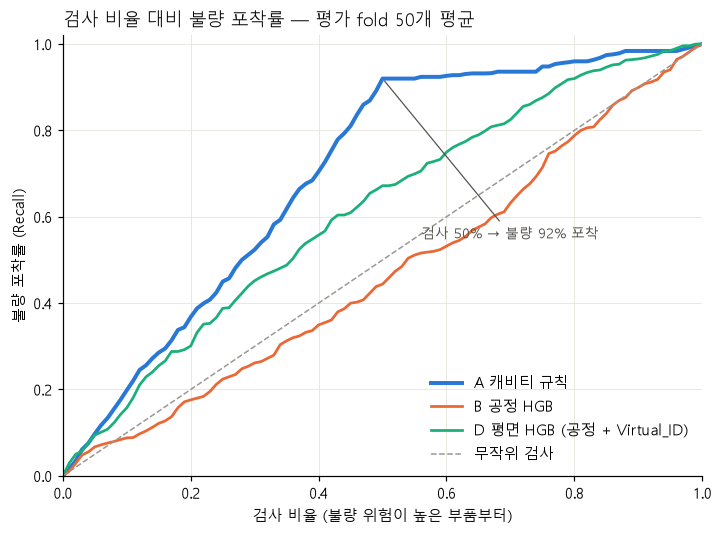

In [21]:
grid = np.linspace(0, 1, 101)

def mean_capture(name):
    curves = []
    for k, (te, s) in enumerate(OOF[name]):
        o = rank_order(s, SEED + k)
        cum = np.r_[0, np.cumsum(y[te][o])] / y[te].sum()
        curves.append(np.interp(grid, np.arange(len(o) + 1) / len(o), cum))
    return np.mean(curves, axis=0)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
for name, c, lw in (('A 캐비티 규칙', C_BLUE, 2.6), ('B 공정 HGB', C_ORANGE, 1.8), ('D 평면 HGB (공정 + Virtual_ID)', '#1baf7a', 1.8)):
    ax.plot(grid, mean_capture(name), color=c, lw=lw, label=name)
ax.plot([0, 1], [0, 1], color=C_GRAY, ls='--', lw=1, label='무작위 검사')
cap_a = mean_capture('A 캐비티 규칙')
ax.annotate(f'검사 50% → 불량 {cap_a[50]:.0%} 포착', (0.5, cap_a[50]), xytext=(0.56, 0.55), fontsize=9, color=INK2,
            arrowprops=dict(arrowstyle='-', color=INK2, lw=0.8))
ax.set_xlabel('검사 비율 (불량 위험이 높은 부품부터)'); ax.set_ylabel('불량 포착률 (Recall)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.legend(loc='lower right', frameon=False)
ax.set_title('검사 비율 대비 불량 포착률 — 평가 fold 50개 평균', loc='left')
fig.savefig(FIG / 'm_capture_curve.png'); plt.show()

### 4-5. 최종 모델: 캐비티별 불량률 모델

전체 데이터로 적합한다. 부품의 불량 확률 = 그 부품 캐비티의 불량률.

In [22]:
final = pd.DataFrame([{'Virtual_ID': v, '부품 수': int((vid == v).sum()), '불량': int(y[vid == v].sum()),
                       '불량률 (= 예측 불량 확률)': (y[vid == v].sum() + 0.5) / ((vid == v).sum() + 1)} for v in (0, 1)])
final['불량 중 비중'] = final['불량'] / final['불량'].sum()
final.to_csv(TAB / 'm_final_model_params.csv', index=False, encoding='utf-8-sig')
final.round(4)

,Virtual_ID,부품 수,불량,불량률 (= 예측 불량 확률),불량 중 비중
0,0,591,23,0.0397,0.92
1,1,591,2,0.0042,0.08


In [23]:
# 팀 공통 특징 중요도: 모든 변수를 넣은 평면 HGB(D)의 평가 fold permutation importance (PR-AUC 감소)
Xf = np.c_[Xp, vid]
FEAT_ALL = PROC + ['Virtual_ID']

def perm_imp(k, tr, te):
    m = hgb().fit(Xf[tr], y[tr])
    r = permutation_importance(m, Xf[te], y[te], scoring='average_precision', n_repeats=5, random_state=SEED)
    return r.importances_mean

imp = np.array(Parallel(n_jobs=-1)(delayed(perm_imp)(k, tr, te) for k, (_, tr, te) in enumerate(SPLITS)))
fi = pd.DataFrame({'model': 'D 평면 HGB (공정 + Virtual_ID)', 'product': 'RG3', 'feature': FEAT_ALL,
                   'importance_mean': imp.mean(0), 'importance_std': imp.std(0, ddof=1),
                   'method': 'permutation importance (PR-AUC 감소, 샷 묶음 5-fold×10 평가 fold 평균)'})
fi = fi.sort_values('importance_mean', ascending=False)
fi.to_csv(TAB / 'feature_importance_RG3.csv', index=False, encoding='utf-8-sig')
fi.head(8)[['feature', 'importance_mean', 'importance_std']].round(4)

,feature,importance_mean,importance_std
47,Virtual_ID,0.0267,0.0344
36,Plasticizing_Time_EMA3,0.0124,0.0342
16,Barrel_Temperature_3,0.0115,0.0290
37,Plasticizing_Time_DIFF,0.0086,0.0433
45,Max_Switch_Over_Pressure_EMA3,0.0079,0.0173
39,Cycle_Time_EMA3,0.0070,0.0292
27,Clamp_Close_Time_EMA3,0.0037,0.0189
38,Cycle_Time_EMA10,0.0030,0.0195


### 4-6. 작동 조건과 실패 조건

In [24]:
# 운영안: 캐비티 0 부품 전수 검사 (검사율 50%) 기준으로, 불량 25건이 어떤 조건에서 잡히고 놓치는지
t_order = df['shot_id'].to_numpy()                        # 샷 순서 = 시간 순서
block = pd.qcut(t_order, 5, labels=[f'{i}구간' for i in range(1, 6)])
cond = pd.DataFrame({'시간 구간': block, 'Virtual_ID': vid, '불량': y, '포착': (y == 1) & (vid == 0),
                     '변화점 이후(idx ≥ 1891)': df.index >= 1891})
by_block = cond[cond['불량'] == 1].groupby('시간 구간', observed=True).agg(불량=('불량', 'sum'), 포착=('포착', 'sum'))
by_block['Recall'] = by_block['포착'] / by_block['불량']
by_regime = cond[cond['불량'] == 1].groupby('변화점 이후(idx ≥ 1891)').agg(불량=('불량', 'sum'), 포착=('포착', 'sum'))
by_regime['Recall'] = by_regime['포착'] / by_regime['불량']
display(by_block, by_regime)

# 시간 순 검증: 앞 70% 샷으로 캐비티 불량률 학습 → 뒤 30% 샷에 적용
cut = np.quantile(np.unique(t_order), 0.7)
tr, te = np.flatnonzero(t_order <= cut), np.flatnonzero(t_order > cut)
s = fit_cavity(tr)(te)
print(f'시간 순 검증: 학습 불량 {y[tr].sum()}건 → 평가 불량 {y[te].sum()}건 | 검사 50%(캐비티 0) Recall = '
      f'{recall_at(y[te], s, 0.5, SEED):.2f} (캐비티 0 불량 {int(y[te][vid[te] == 0].sum())}/{int(y[te].sum())})')

,불량,포착,Recall
시간 구간,,,
1구간,4,4,1.000000
2구간,9,7,0.777778
3구간,3,3,1.000000
4구간,4,4,1.000000
5구간,5,5,1.000000


,불량,포착,Recall
변화점 이후(idx ≥ 1891),,,
False,15,13,0.866667
True,10,10,1.000000


시간 순 검증: 학습 불량 19건 → 평가 불량 6건 | 검사 50%(캐비티 0) Recall = 1.00 (캐비티 0 불량 6/6)


In [25]:
missed = df[(y == 1) & (vid == 1)]
print('놓치는 불량 (캐비티 1):', len(missed), '건 — 원본 인덱스', list(missed.index))
# 놓친 불량이 공정값으로 구별되는가: 캐비티 1 부품 중 불량 2건의 공정 모델(B) 위험 순위
risk = np.zeros(len(y)); cnt = np.zeros(len(y))
for te, s in OOF['B 공정 HGB']:
    risk[te] += s; cnt[te] += 1
risk /= cnt
pct = pd.Series(risk[vid == 1]).rank(pct=True).values
print('캐비티 1 부품 591개 중 공정 위험 백분위:', [f'{p:.0%}' for p in pct[y[vid == 1] == 1]], '(높을수록 위험)')

놓치는 불량 (캐비티 1): 2 건 — 원본 인덱스 [1618, 1674]
캐비티 1 부품 591개 중 공정 위험 백분위: ['17%', '41%'] (높을수록 위험)


### 4-7. 최종 모델 성능 요약

캐비티 규칙의 성능을 팀 공통 지표·순위 지표·검사 우선순위 지표로 정리하고, 같은 조건의 무작위 검사와 비교한다.
모든 값은 샷 묶음 5-fold × 10 평가 fold의 평균 ± 표준편차다.

In [26]:
A = folds[folds['model'] == 'A 캐비티 규칙']
AR = folds[folds['model'] == 'A 캐비티 규칙 (동점 무작위 순서)']
prev = folds['prevalence'].mean()
ms = lambda s: f'{s.mean():.3f} ± {s.std():.3f}'
print('50개 fold 중 임계값이 캐비티 0 전수 검사를 고른 fold:', int((A['검사율_F1max'].between(0.45, 0.55)).sum()), '/', len(A))

perf = pd.DataFrame([
    ('팀 공통 지표 (임계값 = 캐비티 0 검사)', 'F1', ms(A['f1_F1max']), '-', 'F1 최대 임계값과 Recall ≥ 0.8 임계값이 같은 결과'),
    ('팀 공통 지표 (임계값 = 캐비티 0 검사)', 'Precision', ms(A['precision_F1max']), f'{prev:.3f}', '검사한 부품 중 실제 불량 비율'),
    ('팀 공통 지표 (임계값 = 캐비티 0 검사)', 'Recall', ms(A['recall_F1max']), '0.500', '무작위는 같은 검사량(50%) 기준'),
    ('팀 공통 지표 (임계값 = 캐비티 0 검사)', '검사율', ms(A['검사율_F1max']), '0.500', ''),
    ('팀 공통 지표 (순위)', 'PR-AUC (캐비티 안 동점 그대로)', ms(A['prauc']), f'{prev:.3f}', '점수가 두 값뿐이라 낮게 계산됨'),
    ('팀 공통 지표 (순위)', 'PR-AUC (캐비티 안 순서 무작위)', ms(AR['prauc']), f'{prev:.3f}', '동점 영향을 뺀 값'),
    ('참고', 'ROC-AUC', ms(A['roc_auc']), '0.500', ''),
    ('검사 우선순위', 'Recall@상위 5%', ms(A['recall@5%']), '0.050', '위험 높은 부품 5%를 검사했을 때 불량 포착률'),
    ('검사 우선순위', 'Recall@상위 10%', ms(A['recall@10%']), '0.100', ''),
    ('검사 우선순위', 'Recall@상위 20%', ms(A['recall@20%']), '0.200', ''),
    ('검사 우선순위', 'Recall@상위 50%', ms(A['recall@50%']), '0.500', '= 캐비티 0 전수 검사'),
    ('검사 우선순위', '검사율@Recall 0.8', ms(A['검사율@Recall0.8']), '0.800', '불량 80%를 잡는 데 필요한 검사 비율'),
    ('검사 우선순위', '검사율@Recall 1.0', ms(A['검사율@Recall1.0']), '1.000', '평가 fold에 캐비티 1 불량이 있으면 거의 전수'),
], columns=['구분', '지표', '캐비티 규칙 (평균 ± 표준편차)', '무작위 검사', '설명'])
perf.to_csv(TAB / 'm_final_performance.csv', index=False, encoding='utf-8-sig')
perf

50개 fold 중 임계값이 캐비티 0 전수 검사를 고른 fold: 50 / 50


,구분,지표,캐비티 규칙 (평균 ± 표준편차),무작위 검사,설명
0,팀 공통 지표 (임계값 = 캐비티 0 검사),F1,0.075 ± 0.009,-,F1 최대 임계값과 Recall ≥ 0.8 임계값이 같은 결과
1,팀 공통 지표 (임계값 = 캐비티 0 검사),Precision,0.039 ± 0.005,0.021,검사한 부품 중 실제 불량 비율
2,팀 공통 지표 (임계값 = 캐비티 0 검사),Recall,0.920 ± 0.107,0.500,무작위는 같은 검사량(50%) 기준
3,팀 공통 지표 (임계값 = 캐비티 0 검사),검사율,0.500 ± 0.000,0.500,
4,팀 공통 지표 (순위),PR-AUC (캐비티 안 동점 그대로),0.038 ± 0.006,0.021,점수가 두 값뿐이라 낮게 계산됨
5,팀 공통 지표 (순위),PR-AUC (캐비티 안 순서 무작위),0.071 ± 0.054,0.021,동점 영향을 뺀 값
6,참고,ROC-AUC,0.715 ± 0.055,0.500,
7,검사 우선순위,Recall@상위 5%,0.100 ± 0.129,0.050,위험 높은 부품 5%를 검사했을 때 불량 포착률
8,검사 우선순위,Recall@상위 10%,0.200 ± 0.167,0.100,
9,검사 우선순위,Recall@상위 20%,0.376 ± 0.209,0.200,


In [27]:
# 전체 1,182개 부품에 운영 규칙(캐비티 0 검사)을 적용했을 때의 혼동행렬
flag = vid == 0
tp, fn = int((flag & (y == 1)).sum()), int((~flag & (y == 1)).sum())
fp, tn = int((flag & (y == 0)).sum()), int((~flag & (y == 0)).sum())
cm = pd.DataFrame([[tp, fn], [fp, tn]], index=['실제 불량', '실제 양품'], columns=['검사 (캐비티 0)', '검사 안 함 (캐비티 1)'])
cm.to_csv(TAB / 'm_final_confusion_matrix.csv', encoding='utf-8-sig')
P, R = tp / (tp + fp), tp / (tp + fn)
print(f'검사 {tp + fp}개 / {len(y)}개 ({(tp + fp) / len(y):.0%}) | Precision {P:.3f} | Recall {R:.3f} | F1 {2 * P * R / (P + R):.3f} | '
      f'양품을 검사에서 뺀 비율(특이도) {tn / (tn + fp):.3f}')
cm

검사 591개 / 1182개 (50%) | Precision 0.039 | Recall 0.920 | F1 0.075 | 양품을 검사에서 뺀 비율(특이도) 0.509


,검사 (캐비티 0),검사 안 함 (캐비티 1)
실제 불량,23,2
실제 양품,568,589


> - **검사량 절반으로 불량 92%**: 캐비티 0만 검사하면 591개(50%)를 검사해 불량 25건 중 23건을 잡는다. 무작위로 50%를 검사하면 평균 12.5건이다.
> - **Precision 0.039**: 검사한 부품 26개 중 1개꼴로 불량이다. 불량률 자체가 2.1%라 절대값은 낮지만, 무작위 검사(0.021)의 약 1.9배다.
> - **50%보다 적게 검사하면 효율이 그대로**: 캐비티 0 안에서는 순서를 매길 정보가 없어, 상위 5·10·20% 검사의 포착률은 검사 비율의 약 2배(0.10~0.38)에 그친다. 불량 80%를 잡으려면 평균 38%를 검사해야 한다.
> - **재현율 1.0은 어렵다**: 캐비티 1 불량 2건을 잡으려면 캐비티 1까지 검사해야 해 사실상 전수검사다.

# 5. 결론

**최종 모델: 캐비티별 불량률 모델** (`Virtual_ID` 기반)
- 부품 불량 확률: 캐비티 0 = **3.97%**, 캐비티 1 = **0.42%** (4-5 표)
- 운영: **캐비티 0 부품을 우선(전수) 검사**. F1 최대 임계값과 Recall ≥ 0.8 임계값 모두 같은 결론(캐비티 0 검사)을 고른다.

| 근거 | 수치 (샷 묶음 5-fold × 10 평균) |
|---|---|
| 검사 50%(캐비티 0 전수)의 불량 포착 | **Recall 0.92** (전체 23/25). 무작위 검사면 0.50 |
| F1 / Precision / Recall | 0.075 / 0.039 / 0.920 |
| PR-AUC (기준선 0.021) | 0.038 (캐비티 안 동점 그대로) / 0.071 (캐비티 안 순서 무작위) |
| ROC-AUC (참고) | 0.715 |
| 시간 순 검증 (앞 70% 샷 학습 → 뒤 30%) | 뒤 구간 불량 6건 모두 포착 |
| 시간 5구간 / 변화점(idx 1891) 전후 | 구간별 Recall 0.78~1.00, 변화점 전 0.87 · 후 1.00 |

**공정 변수를 넣지 않은 이유**
- B. 공정 변수만 쓴 모델은 무작위 수준이다: PR-AUC 0.038 vs 라벨 순열 0.039 (p = 0.52), ROC-AUC 0.43~0.47.
- C. 공정 위험 × 캐비티는 오히려 나빠진다: 50% 검사 포착 0.79, 공정값을 무작위로 섞은 경우보다 낮음 (p = 0.97).
- C'. 캐비티 순서를 유지하고 캐비티 안에서만 공정 순위를 써도 개선이 없다 (PR-AUC p = 0.26, Recall@20% p = 0.42).
- D. 모든 변수를 넣은 HGB는 50% 검사 포착 0.67로 캐비티 규칙보다 낮다. 중요도도 `Virtual_ID`가 1위이고 공정 변수는 편차보다 작다.

**작동하는 조건과 실패하는 조건**
- 작동: **캐비티 0 부품의 불량** (25건 중 23건). 시간 구간이나 공정 조건 변화(1891 전후)와 관계없이 유지된다.
- 실패: **캐비티 1 부품의 불량 2건** (원본 인덱스 1618, 1674). 공정 위험 순위도 캐비티 1 부품 중 17%, 41% 위치라 공정값으로도 구별되지 않는다.
  재현율 1.0이 필요하면 캐비티 1까지 검사해야 하므로 사실상 전수검사다.
- 원리적 한계: 공정 센서값은 한 샷의 두 부품이 공유하므로, 샷 안에서 어느 부품이 불량인지는 캐비티 정보로만 구별된다.

**전제와 한계**
- `Virtual_ID`가 실제 캐비티를 뜻한다는 가정에 결론이 기댄다. 원본에서 불량 부품을 먼저 기록한 것이라면 정답이 새어 든 변수이고, 결론은 "공정 데이터로는 예측 불가 → 전수검사"로 바뀐다.
  KAMP 원본 1차 가공 데이터(`PART_NAME`·`TimeStamp`)로 확인이 필요하다.
- 불량 25건, 평가 fold당 약 5건이라 fold별 지표의 편차가 크다.
- 비라벨 데이터는 샷의 약 21%만 두 부품 기록이 남아 있어, 대부분 샷에서 캐비티를 식별할 수 없다. 비라벨 예측에 적용할 때 이 제약이 있다.